# Cohens Kappa – einfach erklärt

> Quelle: [numiqo.de](https://numiqo.de/tutorial/cohens-kappa)

**Cohens Kappa (κ)** misst die **Inter-Rater-Reliabilität** zwischen zwei Beurteilern
bei **nominalen Daten** – bereinigt um zufällige Übereinstimmung.

**Formel:**
$$\kappa = \frac{p_o - p_e}{1 - p_e}$$

| Symbol | Bedeutung |
|---|---|
| $p_o$ | Beobachtete Übereinstimmung = Diagonalsumme / n |
| $p_e$ | Erwartete Übereinstimmung (zufällig) = $\sum_k P(\text{Rater1}=k) \cdot P(\text{Rater2}=k)$ |

**Interpretation (Landis & Koch, 1977):**

| κ | Übereinstimmung |
|---|---|
| > 0,8 | Fast perfekt |
| > 0,6 | Substanziell |
| > 0,4 | Moderat |
| > 0,2 | Mäßig |
| 0 – 0,2 | Gering |
| < 0 | Mangelhaft |

**Wann Cohens Kappa?**
- **2 Rater**, **nominale** Variable
- Bei ordinal → Gewichtetes Kappa
- Bei 3+ Rater → Fleiss Kappa
- Misst **Reliabilität** (nicht Validität!)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import cohen_kappa_score, confusion_matrix

np.random.seed(42)
print("Bibliotheken erfolgreich geladen.")

Bibliotheken erfolgreich geladen.


## 1. Das numiqo-Beispiel: Depressions-Diagnose (n=50)

Zwei Ärzte bewerten 50 Patienten als „depressiv" oder „nicht depressiv".

**Kreuztabelle (numiqo):**

| | Rater2: nicht dep. | Rater2: depressiv | Summe |
|---|---|---|---|
| **Rater1: nicht dep.** | 17 | 8 | 25 |
| **Rater1: depressiv** | 6 | 19 | 25 |
| **Summe** | 23 | 27 | 50 |

**Erwartetes numiqo-Ergebnis:** κ = 0,44 → moderate Übereinstimmung

In [ ]:
# numiqo-Datensatz: Kreuztabelle direkt vorgegeben
# Reihenfolge: TN=17, FP=8, FN=6, TP=19
n = 50
# Konfusionsmatrix: Rater1 (Zeilen) vs. Rater2 (Spalten)
# 0 = nicht depressiv, 1 = depressiv
cm = np.array([[17, 8],
               [6, 19]])

# Daraus einzelne Ratings rekonstruieren
rater1 = np.array([0]*25 + [1]*25)
rater2 = np.array([0]*17 + [1]*8 + [0]*6 + [1]*19)

# po: beobachtete Übereinstimmung
po = (cm[0,0] + cm[1,1]) / n
print("Schritt-für-Schritt: Cohens Kappa")
print()
print("Kreuztabelle:")
print("                 Rater2: nicht dep.  Rater2: dep.")
print("Rater1: nicht dep.  " + str(cm[0,0]) + "                  " + str(cm[0,1]))
print("Rater1: dep.        " + str(cm[1,0]) + "                   " + str(cm[1,1]))
print()
print("po (beobachtet) = (" + str(cm[0,0]) + "+" + str(cm[1,1]) + ") / " +
      str(n) + " = " + str(round(po, 4)))
print()

# pe: erwartete Zufall-Übereinstimmung
p1_0 = cm[0,:].sum() / n  # Rater1 sagt 0
p1_1 = cm[1,:].sum() / n  # Rater1 sagt 1
p2_0 = cm[:,0].sum() / n  # Rater2 sagt 0
p2_1 = cm[:,1].sum() / n  # Rater2 sagt 1

pe = p1_0 * p2_0 + p1_1 * p2_1
print("pe (erwartet):")
print("  P(R1=0) = " + str(cm[0,:].sum()) + "/" + str(n) + " = " + str(round(p1_0, 4)))
print("  P(R2=0) = " + str(cm[:,0].sum()) + "/" + str(n) + " = " + str(round(p2_0, 4)))
print("  P(R1=1) = " + str(cm[1,:].sum()) + "/" + str(n) + " = " + str(round(p1_1, 4)))
print("  P(R2=1) = " + str(cm[:,1].sum()) + "/" + str(n) + " = " + str(round(p2_1, 4)))
print("  pe = " + str(round(p1_0,4)) + "*" + str(round(p2_0,4)) +
      " + " + str(round(p1_1,4)) + "*" + str(round(p2_1,4)) +
      " = " + str(round(pe, 4)) + "  (numiqo: 0.50)")
print()

# Kappa
kappa_man = (po - pe) / (1 - pe)
kappa_sci = cohen_kappa_score(rater1, rater2)
print("kappa = (" + str(round(po,4)) + " - " + str(round(pe,4)) +
      ") / (1 - " + str(round(pe,4)) + ")")
print("kappa = " + str(round(kappa_man, 4)) + "  (numiqo: 0.44)")
print("scipy: " + str(round(kappa_sci, 4)))
print()

def interpret_kappa(k):
    if k > 0.8: return "fast perfekt"
    elif k > 0.6: return "substanziell"
    elif k > 0.4: return "moderat"
    elif k > 0.2: return "mäßig"
    elif k >= 0: return "gering"
    return "mangelhaft"

print("Interpretation: kappa=" + str(round(kappa_man, 3)) +
      " -> " + interpret_kappa(kappa_man))

Schritt-für-Schritt: Cohens Kappa

Kreuztabelle:
                 Rater2: nicht dep.  Rater2: dep.
Rater1: nicht dep.  17                  8
Rater1: dep.        6                   19

po (beobachtet) = (17+19) / 50 = 0.72

pe (erwartet):
  P(R1=0) = 25/50 = 0.5
  P(R2=0) = 23/50 = 0.46
  P(R1=1) = 25/50 = 0.5
  P(R2=1) = 27/50 = 0.54
  pe = 0.5*0.46 + 0.5*0.54 = 0.5  (numiqo: 0.50)

kappa = (0.72 - 0.5) / (1 - 0.5)
kappa = 0.44  (numiqo: 0.44)
scipy: 0.44

Interpretation: kappa=0.44 -> moderat


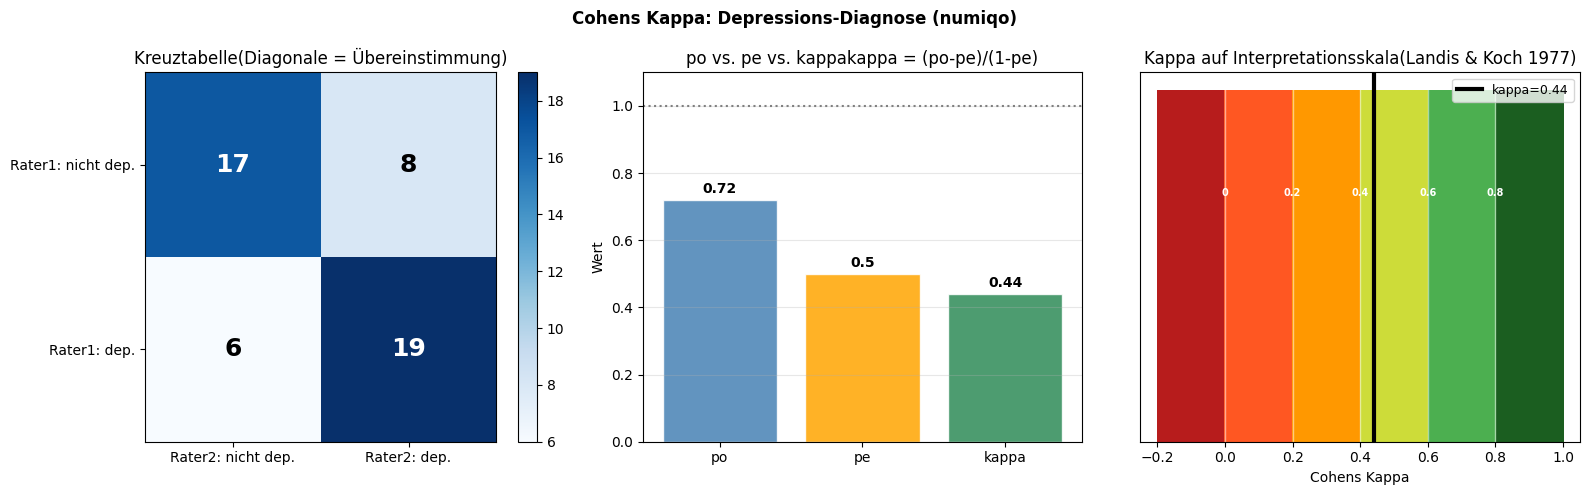

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Cohens Kappa: Depressions-Diagnose (numiqo)", fontsize=12,
             fontweight="bold")

# 1. Kreuztabelle als Heatmap
im = axes[0].imshow(cm, cmap="Blues", aspect="auto")
plt.colorbar(im, ax=axes[0])
kategorien = ["Nicht dep.", "Depressiv"]
axes[0].set_xticks([0, 1])
axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(["Rater2: nicht dep.", "Rater2: dep."])
axes[0].set_yticklabels(["Rater1: nicht dep.", "Rater1: dep."])
for i in range(2):
    for j in range(2):
        farbe = "diag" if i == j else "off"
        axes[0].text(j, i, str(cm[i,j]),
                     ha="center", va="center", fontsize=18, fontweight="bold",
                     color="white" if cm[i,j] > 15 else "black")
axes[0].set_title("Kreuztabelle(Diagonale = Übereinstimmung)")

# 2. po vs. pe visualisieren
balken_daten = [po, pe, kappa_man]
balken_farben = ["steelblue", "orange", "seagreen"]
balken_namen = ["po", "pe", "kappa"]
bars = axes[1].bar(balken_namen, balken_daten, color=balken_farben,
                   edgecolor="white", alpha=0.85)
axes[1].axhline(1, color="gray", linestyle=":", linewidth=1.5)
axes[1].set_title("po vs. pe vs. kappakappa = (po-pe)/(1-pe)")
axes[1].set_ylabel("Wert")
axes[1].set_ylim(0, 1.1)
axes[1].grid(axis="y", alpha=0.3)
for bar, val in zip(bars, balken_daten):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.02,
                 str(round(val, 3)), ha="center", fontsize=10, fontweight="bold")

# 3. Kappa-Interpretationsskala
kappa_werte = np.linspace(-0.2, 1.0, 300)
farben_skala = []
for k in kappa_werte:
    if k > 0.8:   farben_skala.append("#1B5E20")
    elif k > 0.6: farben_skala.append("#4CAF50")
    elif k > 0.4: farben_skala.append("#CDDC39")
    elif k > 0.2: farben_skala.append("#FF9800")
    elif k >= 0:  farben_skala.append("#FF5722")
    else:         farben_skala.append("#B71C1C")
axes[2].bar(kappa_werte, [1]*300, width=0.005, color=farben_skala, edgecolor="none")
axes[2].axvline(kappa_man, color="black", linewidth=3,
                label="kappa=" + str(round(kappa_man, 2)))
for grenze, label in [(0.8,"fast perfekt"), (0.6,"substanziell"),
                       (0.4,"moderat"), (0.2,"mäßig"), (0,"gering")]:
    axes[2].axvline(grenze, color="white", linewidth=1, alpha=0.5)
    axes[2].text(grenze, 0.7, str(grenze), ha="center", fontsize=7, color="white",
                 fontweight="bold")
axes[2].set_title("Kappa auf Interpretationsskala(Landis & Koch 1977)")
axes[2].set_xlabel("Cohens Kappa")
axes[2].set_yticks([])
axes[2].legend(fontsize=9)
axes[2].set_xlim(-0.25, 1.05)

plt.tight_layout()
plt.show()

In [4]:
# Verschiedene Übereinstimmungsniveaus demonstrieren
print("Verschiedene Übereinstimmungsniveaus")
print()

szenarien = [
    ("Fast perfekt (kappa>0.8)", np.array([0,0,0,0,0,1,1,1,1,1]),
                                 np.array([0,0,0,0,1,1,1,1,1,1])),
    ("Moderat (kappa~0.4)",      np.array([0,0,0,1,1,0,1,1,0,1]),
                                 np.array([0,0,1,0,1,1,0,1,1,1])),
    ("Zufall (kappa~0)",         np.array([0,0,1,1,0,1,0,1,0,1]),
                                 np.array([1,0,0,1,1,0,1,0,1,0])),
]

for name, r1, r2 in szenarien:
    k = cohen_kappa_score(r1, r2)
    po_s = (r1 == r2).mean()
    print(name)
    print("  po=" + str(round(po_s,3)) + "  kappa=" + str(round(k,3)) +
          "  -> " + interpret_kappa(k))
    print()

Verschiedene Übereinstimmungsniveaus

Fast perfekt (kappa>0.8)
  po=0.9  kappa=0.8  -> substanziell

Moderat (kappa~0.4)
  po=0.5  kappa=0.0  -> gering

Zufall (kappa~0)
  po=0.2  kappa=-0.6  -> mangelhaft



In [6]:
# APA-Ausgabe-Funktion
def cohens_kappa_apa(rater1_v, rater2_v, beschreibung="Rater1 vs. Rater2"):
    rater1_v = np.asarray(rater1_v)
    rater2_v = np.asarray(rater2_v)
    n_f = len(rater1_v)
    k_f = cohen_kappa_score(rater1_v, rater2_v)
    po_f = (rater1_v == rater2_v).mean()

    interp = interpret_kappa(k_f)
    print("Cohens Kappa: " + beschreibung)
    print("n=" + str(n_f))
    print("po=" + str(round(po_f, 4)) + "  kappa=" + str(round(k_f, 4)))
    print("Interpretation: " + interp)
    print()
    print("APA: Eine Inter-Rater-Reliabilitätsanalyse wurde")
    print("zwischen " + beschreibung + " durchgeführt.")
    print("Das Cohens Kappa zeigte eine " + interp + "e Übereinstimmung,")
    print("k=" + str(round(k_f, 2)) + ".")
    print()

cohens_kappa_apa(rater1, rater2, "Arzt1 vs. Arzt2 (Depression)")

Cohens Kappa: Arzt1 vs. Arzt2 (Depression)
n=50
po=0.72  kappa=0.44
Interpretation: moderat

APA: Eine Inter-Rater-Reliabilitätsanalyse wurde
zwischen Arzt1 vs. Arzt2 (Depression) durchgeführt.
Das Cohens Kappa zeigte eine moderate Übereinstimmung,
k=0.44.



## 2. Zusammenfassung

```
Cohens Kappa – Übersicht
│
├── WAS?
│   Mass für Inter-Rater-Reliabilitaet
│   Bereinigt um zufaellige Übereinstimmung
│   2 Rater, nominale Variable
│
├── FORMEL
│   kappa = (po - pe) / (1 - pe)
│   po = beobachtete Übereinstimmung (Diagonale/n)
│   pe = erwartete Zufall-Übereinstimmung
│        = Sum_k [P(R1=k) * P(R2=k)]
│
├── INTERPRETATION (Landis & Koch 1977)
│   > 0.8:  fast perfekt
│   > 0.6:  substanziell
│   > 0.4:  moderat
│   > 0.2:  maessig
│   0 - 0.2: gering
│   < 0:    mangelhaft
│
├── VARIANTEN
│   Cohens Kappa:      2 Rater, nominal
│   Gewichtetes Kappa: 2 Rater, ordinal (Abstufungen berücksichtigt)
│   Fleiss Kappa:      3+ Rater, nominal
│
├── WICHTIG: Reliabilitaet != Validitaet!
│   Kappa sagt nur: Messen beide das GLEICHE?
│   Nicht: Messen beide das RICHTIGE?
│
├── numiqo-BEISPIEL: Depression (n=50)
│   po=0.72, pe=0.50, kappa=0.44 -> moderat
│
└── PYTHON
    from sklearn.metrics import cohen_kappa_score
    kappa = cohen_kappa_score(rater1, rater2)
```

---
Quelle: [numiqo.de/tutorial/cohens-kappa](https://numiqo.de/tutorial/cohens-kappa)